<a href="https://colab.research.google.com/github/huamanchristian44/Lab-13-HE/blob/develop/Laboratorio_13_Mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Laboratorio 13: Comparación del desempeño de modelos**

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform

In [13]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/garments_worker_productivity.csv')

In [14]:
# Eliminar la columna 'date'
df.drop(columns='date', inplace=True)

In [15]:
# Crear variable de clasificación binaria
df['productivity_class'] = np.where(df['actual_productivity'] < 0.5, 0, 1)

In [16]:
# Eliminar la original si ya no la usaremos como predictor
df.drop('actual_productivity', axis=1, inplace=True)

In [17]:
# Ver datos faltantes
print(df.isnull().sum())

quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
productivity_class         0
dtype: int64


In [18]:
# Eliminando la variable wip
df.drop(columns='wip', inplace=True)

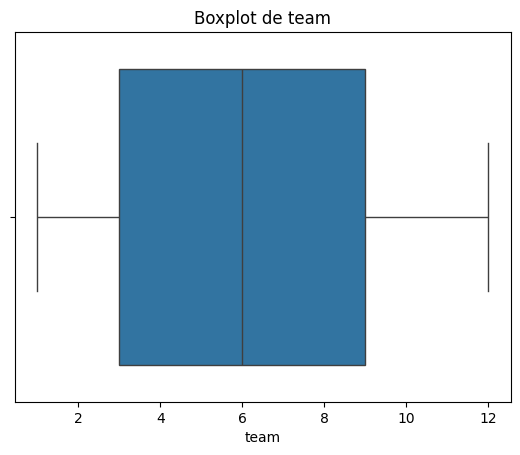

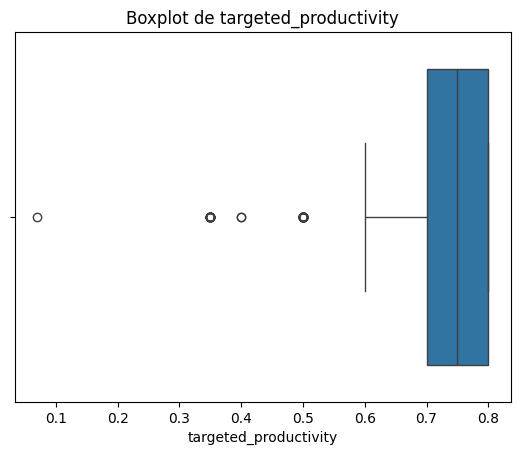

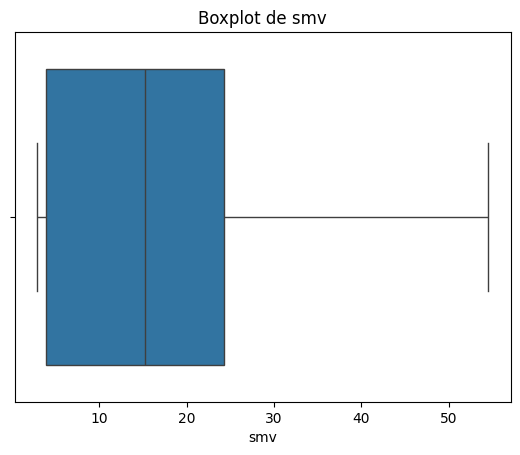

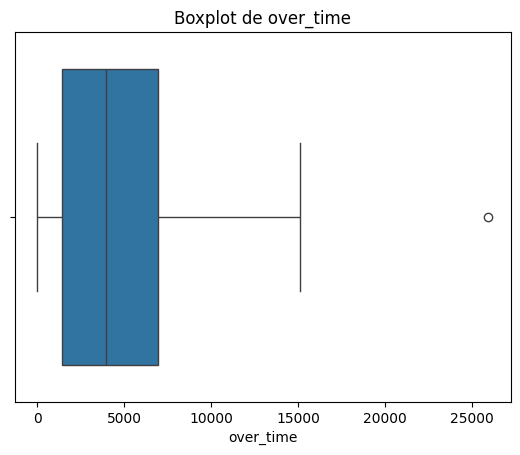

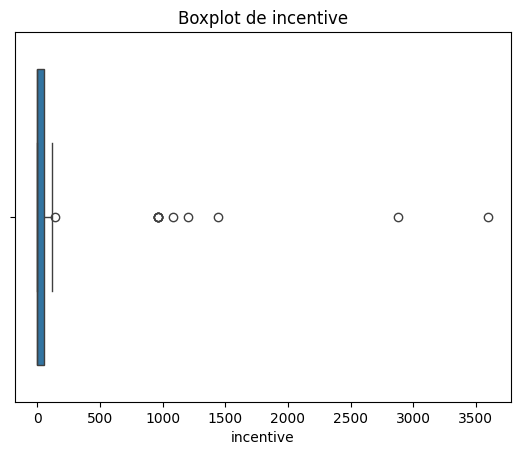

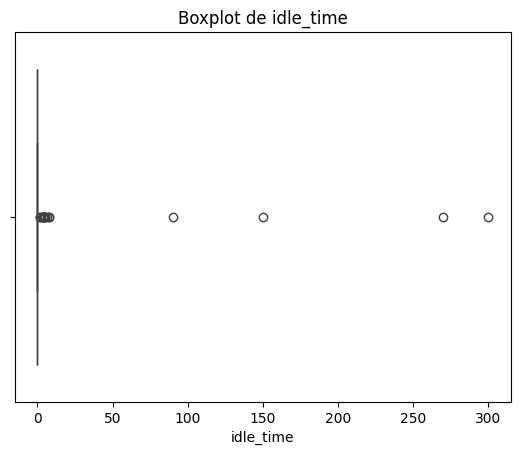

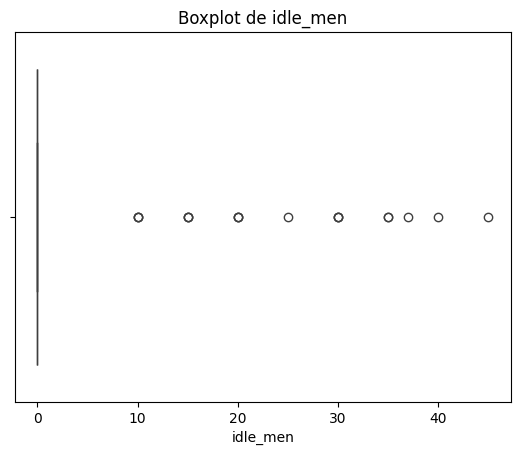

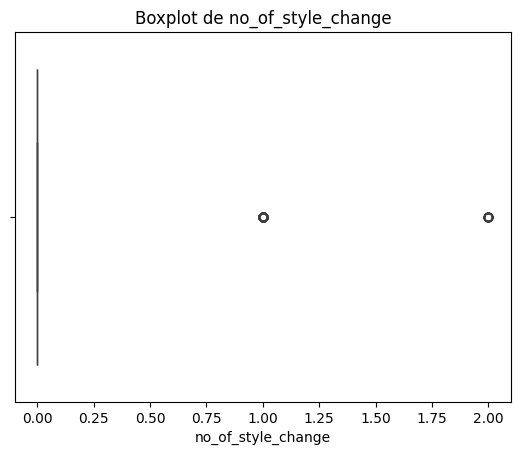

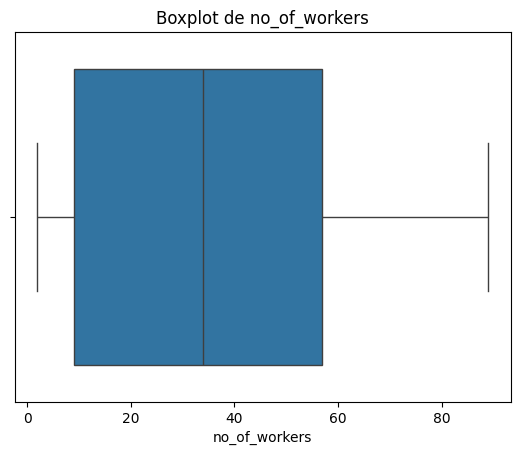

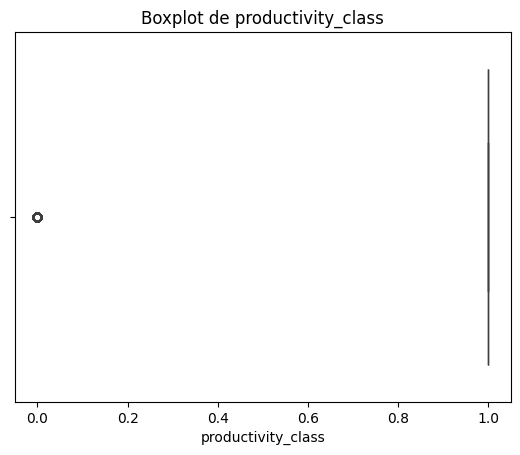

In [19]:
# Univariado
numericas = df.select_dtypes(include=np.number).columns.tolist()
for col in numericas:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

In [20]:
#Winsorización
for col in numericas:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

In [21]:
# Variables categóricas
df = pd.get_dummies(df, drop_first=True)

In [22]:
# Separar variables X e y
X = df.drop('productivity_class', axis=1)
y = df['productivity_class']

In [23]:
# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
modelos = {
    "kNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB()
}

In [26]:
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{nombre} Accuracy: {acc:.4f}")

kNN Accuracy: 0.8917
SVM Accuracy: 0.9000
Logistic Regression Accuracy: 0.8875
Decision Tree Accuracy: 0.8875
Random Forest Accuracy: 0.9125
Naive Bayes Accuracy: 0.8667


In [27]:
# Ejemplo con Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Mejor modelo (GridSearch):", grid_search.best_params_)
print("Accuracy:", grid_search.score(X_test, y_test))

Mejor modelo (GridSearch): {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 50}
Accuracy: 0.8958333333333334


In [28]:
param_dist = {
    'C': uniform(0.1, 10),
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

random_search = RandomizedSearchCV(SVC(), param_distributions=param_dist, n_iter=20, cv=5, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVC(), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c3d51cf0d0>,
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'rbf', 'poly']},
                   random_state=42)

In [29]:
print("Mejor modelo (RandomSearch):", random_search.best_params_)
print("Accuracy:", random_search.score(X_test, y_test))

Mejor modelo (RandomSearch): {'C': np.float64(0.5645041271999772), 'gamma': 'scale', 'kernel': 'poly'}
Accuracy: 0.8958333333333334


In [30]:
mejor_modelo = grid_search.best_estimator_
mejores_hiperparametros = grid_search.best_params_
accuracy_final = accuracy_score(y_test, mejor_modelo.predict(X_test))

print("Mejor modelo ajustado:", mejor_modelo)
print("Mejores hiperparámetros:", mejores_hiperparametros)
print("Accuracy final en test:", accuracy_final)

Mejor modelo ajustado: RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=50)
Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 50}
Accuracy final en test: 0.8958333333333334
